<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>💎Diamonds</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[  ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

In [ ]:
# from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json file is stored in Google Drive

<details>
  <summary><a href="https://www.kaggle.com/docs/api">Kagle API</a> downloads data with credentials in <i>kaggle.json</i></summary>
  <div>

**Hint**: Use [LLM](https://en.wikipedia.org/wiki/Large_language_model) (Gemini, ChatGPT, DeepSeek, Meta, etc.) to learn about unfamiliar commands below.

1. `!` runs in-line [BASH](https://en.wikipedia.org/wiki/Bash_(Unix_shell)) command in Colab's [Ubuntu](https://en.wikipedia.org/wiki/Ubuntu) OS
  1. [`%%bash`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#cell-magics) magic command runs all code in the code cell via BASH (no need for line-level `!` then)
1. `kaggle` is the Kaggle API executable.
  1. Colab's Python environment comes it, but if you experiment elsewhere (e.g. local PC or AWS Sagemaker), you may need to [install it](https://www.kaggle.com/docs/api#getting-started-installation-&-authentication) (once) with `pip install kaggle` (see `!` above).
1. <a href="https://en.wikipedia.org/wiki/API">API</a> looks for `kaggle.json` in `.kaggle` hidden folder in `root` of Colab's directory, so we copy the file there
1. We ask `kaggle` to remember the competition name and ask it to download the zipped data file and print the leaderboard (LB)
  
  </div>

In [ ]:
!mkdir -p ~/.kaggle                           # Kaggle exe uses kaggle.json in root's hidden .kaggle dir
!cp kaggle.json ~/.kaggle/kaggle.json >> log  # If kaggle.json in Colab's content dir (without GDrive)
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >>log  # If kaggle.json is in GDrive's root
!chmod 600 ~/.kaggle/kaggle.json              # Only you have full read/write access to kaggle.json
!kaggle config set -n competition -v 260120diamonds  # Set competition context for API calls heresince
!kaggle competitions download >> log          # Download competition data as a zip file
!unzip -o *.zip >> log                        # Unzip Kaggle data
!kaggle competitions leaderboard --show       # Print current public LB. See www.kaggle.com/docs/api

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
- competition is now set to: 260120diamonds
100% 3.30M/3.30M [00:00<00:00, 1.05GB/s]
Using competition: 260120diamonds
  teamId  teamName                        submissionDate              score            
--------  ------------------------------  --------------------------  ---------------  
15164859  Team6_Landa_Cahill_Hito_Palmer  2026-02-01 03:17:23.516000  527.1341794999   
15128186  7_Gaven_Ivan_Nitisha_Charles    2026-01-31 18:04:20.343000  527.2258208325   
15139317  3_TheMatrix                     2026-02-01 02:50:09.710000  551.2526095000   
15134430  💎 4                             2026-01-28 16:09:55.663000  564.2785285000   
15165319  2_Appel_callaghan_ho            2026-01-31 20:44:06.676000  595.8149354999   
15179932  💎 5                             2026-02-01 08:31:21.303000  596.8968110000   
15138850  DanLJHU                         2026-01-30 03:26:04.636000  630.6136715000   
15155588 

<details>
  <summary>Prepare packages, timer, GPU seeding, output formatting</summary>
  <div>

1. `%%time` magic command measures runtime of the whole cell
1. `%%capture` redirects output to a file
1. `%reset -f` forces deletion of imported packages, variables and functions
1. `InteractiveShell` enables multi-output from any code cell in Colab. By default, only last output is printed (in a single cell), unless you use `print()` for every output in a single cell
1. `Timer()`: object to time student's code in TGP section below

  </div>

In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 115 ms, sys: 1.05 ms, total: 116 ms
Wall time: 116 ms


In [ ]:
df = pd.read_csv('XY_diamonds.csv'); df

,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.35,67.2,57.1,4.64,4.69,2.87,I,G,VS1,NaN
1,1.64,67.3,60.7,7.84,7.82,4.94,V,E,SI1,NaN
...,...,...,...,...,...,...,...,...,...,...
199998,0.48,68.7,53.0,4.47,4.45,2.72,I,G,IF,1474.0
199999,0.48,65.0,64.7,5.60,5.62,3.44,I,H,VS2,765.0


In [ ]:
df.price.info()  # You must price 40k diamonds, and can train on 160k (with prices)

<class 'pandas.core.series.Series'>
RangeIndex: 200000 entries, 0 to 199999
Series name: price
Non-Null Count   Dtype  
--------------   -----  
160000 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


In [ ]:
vX = df.query('price!=price').drop('price', axis=1)  # slice a test sample, price!=price is True for NaN values
tXY = df.query('price==price')                       # slice a training sample, price==price is True for non-NaN values
tX, tY = tXY.drop('price', axis=1), tXY.price        # split into training I/O

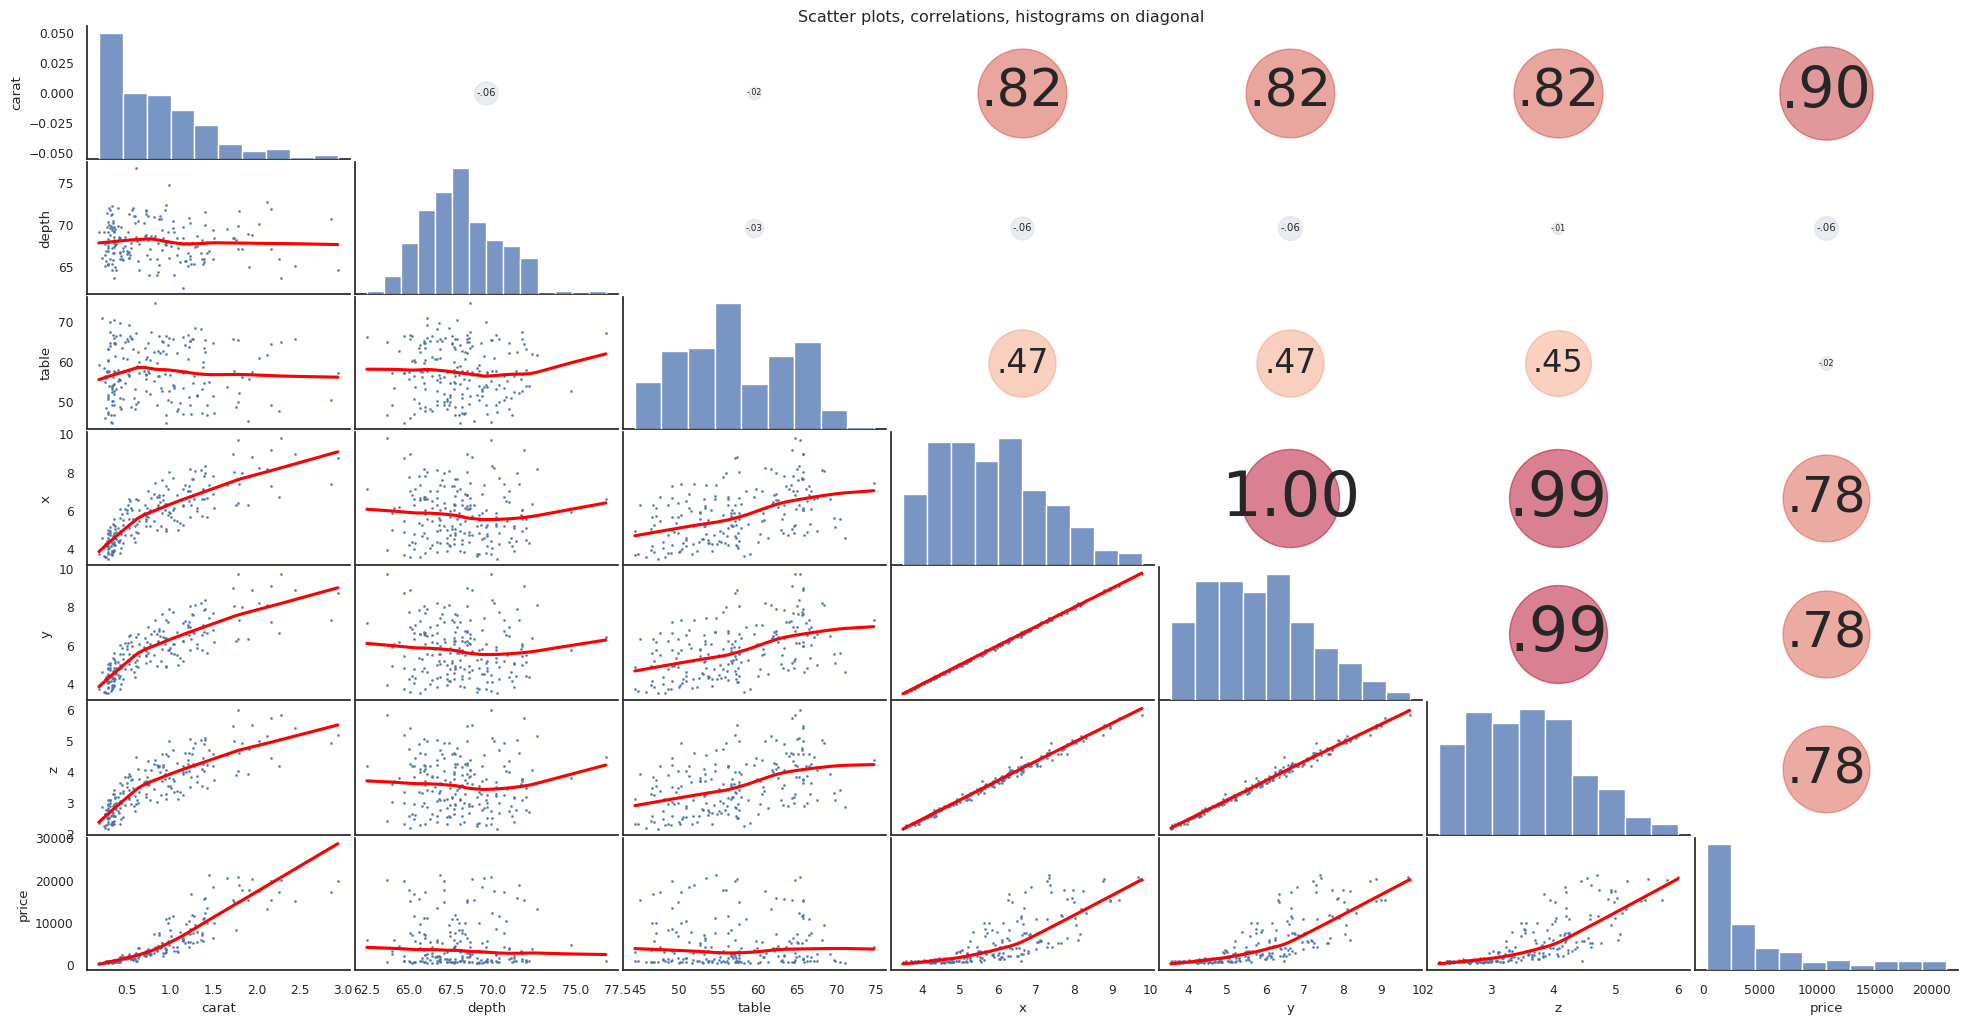

CPU times: user 3.41 s, sys: 37.1 ms, total: 3.45 s
Wall time: 3.49 s


In [ ]:
def ScatterCorrHist(df):  # quick EDA on linear and non-linear X-Y relations
  def corrdot(*args, **kwargs):
    # credit: https://stackoverflow.com/questions/48139899
    corr_r = args[0].corr(args[1], 'pearson')
    corr_text = f"{corr_r:2.2f}".replace("0.", ".")
    ax = plt.gca();
    ax.set_axis_off();
    msz = abs(corr_r) * 5000   # marker size
    fsz = abs(corr_r) * 40 + 5 # font size
    ax.scatter([.5], [.5], msz, [corr_r], alpha=0.5, cmap='coolwarm', vmin=-1, vmax=1, transform=ax.transAxes)
    ax.annotate(corr_text, [.5, .5,],  xycoords="axes fraction", ha='center', va='center', fontsize=fsz)

  sns.set(style='white', font_scale=.8);
  g = sns.PairGrid(df, aspect=1, diag_sharey=False);
  g.fig.set_size_inches(20,10)
  g.map_lower(sns.regplot, lowess=True, ci=False, line_kws={'color':'red'}, scatter_kws={'s':1});
  g.map_diag(sns.histplot, kde_kws={'color':'black'});
  g.map_upper(corrdot);
  g.fig.suptitle("Scatter plots, correlations, histograms on diagonal", y=1);
  _ = plt.subplots_adjust(hspace=0.02, wspace=0.02);
  _ = plt.show();

%time ScatterCorrHist(tXY.head(200))  # disable before submissions. Runs 5-10sec for 200 examples

In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 274 ms, sys: 1.11 ms, total: 275 ms
Wall time: 277 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 113 ms, sys: 992 µs, total: 114 ms
Wall time: 114 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 103 ms, sys: 17 µs, total: 103 ms
Wall time: 103 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 105 ms, sys: 1.07 ms, total: 106 ms
Wall time: 106 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 102 ms, sys: 72 µs, total: 102 ms
Wall time: 101 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 98.2 ms, sys: 44 µs, total: 98.2 ms
Wall time: 97.9 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 115 ms, sys: 0 ns, total: 115 ms
Wall time: 116 ms


In [ ]:
%%time
%%capture log_imports
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 101 ms, sys: 967 µs, total: 102 ms
Wall time: 102 ms


In [ ]:
tmr = Timer()

⏳ started. You have 60 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

In [ ]:
import os
import sys

venv_path = os.path.join(os.getcwd(), ".venv")
if venv_path not in sys.executable:
    print("WARNING: Not running in project .venv.")
    print("Current Python:", sys.executable)
    print("Select kernel: .venv (EN.605.742)")
else:
    print("Using project .venv:", sys.executable)


Current Python: /usr/bin/python3
Select kernel: .venv (EN.605.742)


In [ ]:
# Ensure training/test splits exist when running out of order
if "tX" not in globals() or "tY" not in globals():
    if "df" not in globals():
        df = pd.read_csv("XY_diamonds.csv")
    tXY = df.query("price==price")
    tX, tY = tXY.drop("price", axis=1), tXY.price
    vX = df.query("price!=price").drop("price", axis=1)
    print("Initialized tX, tY, vX from df")
else:
    print("tX and tY already initialized")


Initialized tX, tY, vX from df


<font color=green><h3><b>$\alpha$. Feature engineering</b><h3>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Basic preprocessing: log-transform and winsorize key skewed features
_tX = tX.copy()
_vX = vX.copy()

_tX["volume"] = _tX["x"] * _tX["y"] * _tX["z"]
_vX["volume"] = _vX["x"] * _vX["y"] * _vX["z"]

_tX["carat_log"] = np.log1p(_tX["carat"])
_vX["carat_log"] = np.log1p(_vX["carat"])
_tX["volume_log"] = np.log1p(_tX["volume"])
_vX["volume_log"] = np.log1p(_vX["volume"])

winsor_cols = ["carat_log", "volume_log"]
quantiles = _tX[winsor_cols].quantile([0.01, 0.99])
low = quantiles.loc[0.01]
high = quantiles.loc[0.99]
_tX[winsor_cols] = _tX[winsor_cols].clip(lower=low, upper=high, axis=1)
_vX[winsor_cols] = _vX[winsor_cols].clip(lower=low, upper=high, axis=1)

# Feature derivations
_tX["aspect_ratio"] = _tX["x"] / _tX["y"].replace(0, np.nan)
_vX["aspect_ratio"] = _vX["x"] / _vX["y"].replace(0, np.nan)

_tX["surface_area"] = np.pi * _tX["x"] * _tX["y"] / 4
_vX["surface_area"] = np.pi * _vX["x"] * _vX["y"] / 4

_tX["table_depth_ratio"] = _tX["table"] / _tX["depth"].replace(0, np.nan)
_vX["table_depth_ratio"] = _vX["table"] / _vX["depth"].replace(0, np.nan)

_tX["carat_per_volume"] = _tX["carat"] / _tX["volume"].replace(0, np.nan)
_vX["carat_per_volume"] = _vX["carat"] / _vX["volume"].replace(0, np.nan)

_tX["carat_per_surface_area"] = _tX["carat"] / _tX["surface_area"].replace(0, np.nan)
_vX["carat_per_surface_area"] = _vX["carat"] / _vX["surface_area"].replace(0, np.nan)

_tX = _tX.fillna(0)
_vX = _vX.fillna(0)

tX0 = _tX.iloc[:20000, :]   # subsample for experimentation
tY0 = tY[:20000]   # subsample for experimentation

poly = PolynomialFeatures(degree=2)
tX0_in = poly.fit_transform(tX0.select_dtypes(include=np.number))
vX_in = poly.transform(_vX.select_dtypes(include=np.number))

**Preprocessing update (TGP):** log-transformed `carat` and `volume` then winsorized those logs at the 1st–99th percentiles; engineered `aspect_ratio`, `surface_area`, `table_depth_ratio`, `carat_per_volume`, and `carat_per_surface_area` to enrich geometry signals before polynomial expansion.

<font color=green><h3><b>$\beta$. Model fitting</b><h3>


In [ ]:
# m = LinearRegression()
# m.fit(tX0_in, tY0)

<font color=green><h3><b>$\gamma$. Predict and post-process</font>



TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=RidgeCV(alphas=array([  0.01,   0.03,   0.1 ,   0.32,   1.  ,   3.16,  10.  ,  31.62, 100.  ])))

Local MAE (RidgeCV log-target, best alpha=1.0): 603.5576450822605


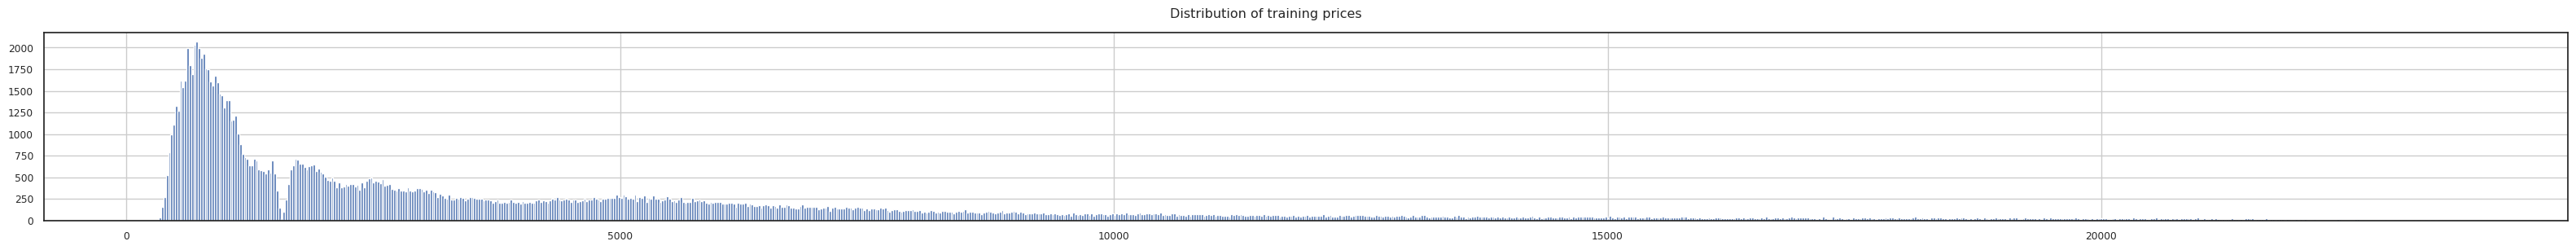

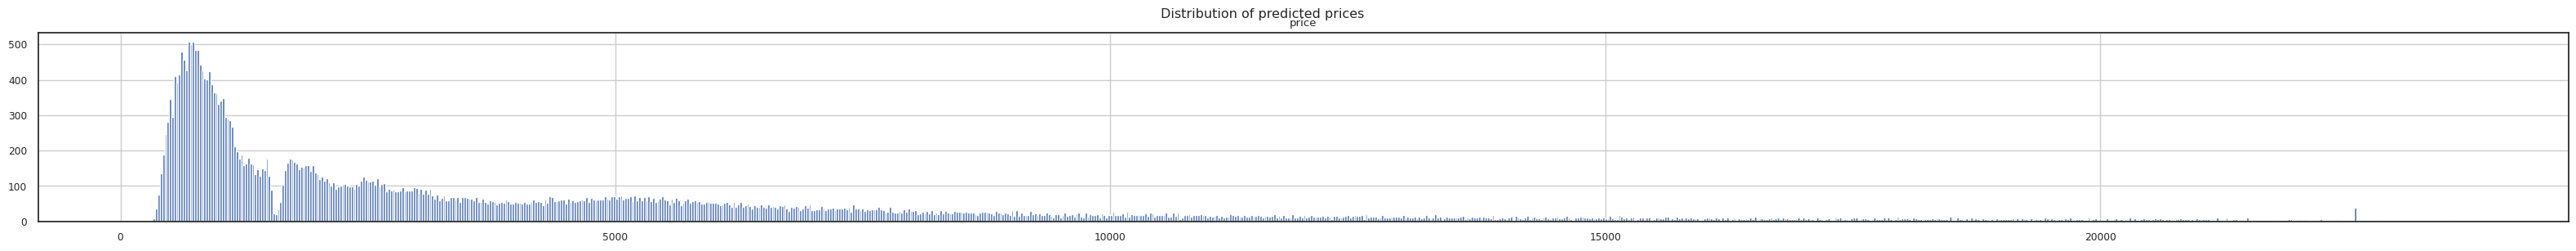

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import RidgeCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler

# Local MAE workflow (RidgeCV + log-target, 80/20 split, one-hot + polynomial interactions)
X_all = pd.get_dummies(_tX, columns=_tX.select_dtypes(exclude=np.number).columns, drop_first=False)
vX_all = pd.get_dummies(_vX, columns=_vX.select_dtypes(exclude=np.number).columns, drop_first=False)
vX_all = vX_all.reindex(columns=X_all.columns, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(X_all, tY, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_in = poly.fit_transform(X_train)
X_val_in = poly.transform(X_val)
vX_in = poly.transform(vX_all)

scaler = StandardScaler()
X_train_in = scaler.fit_transform(X_train_in)
X_val_in = scaler.transform(X_val_in)
vX_in = scaler.transform(vX_in)

alphas = np.logspace(-2, 2, 9)
base = RidgeCV(alphas=alphas)
m = TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)
m.fit(X_train_in, y_train)
val_pred = m.predict(X_val_in)
print(f"Local MAE (RidgeCV log-target, best alpha={m.regressor_.alpha_}):", mean_absolute_error(y_val, val_pred))

pY = pd.DataFrame(m.predict(vX_in), index=range(1,len(vX)+1), columns=['price'])  # ensure that labels and observations are in corresponding order
pY = pY.clip(lower=10)  # ensures no negative prices

# Post-processing: match prediction quantiles to training distribution
q = np.linspace(0.0, 1.0, 1001)
py_q = np.quantile(pY["price"], q)
ty_q = np.quantile(tY, q)
pY["price"] = np.interp(pY["price"], py_q, ty_q)

_ = tY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of training prices");
_ = pY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of predicted prices");
ToCSV = lambda df, fname: (os.makedirs('submissions', exist_ok=True) or df.round(2).to_csv(f'submissions/{fname}.csv', index_label='id')) # rounds values to 2 decimals
ToCSV(pY, '💎Baseline')

<font color=green><h3><b>$\epsilon$. Idea Documentation (JHU students only)</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Clipping outliers + geometry features improves local MAE.
1. **Idea Discovery**: Based on the preprocessing starter ideas, I tried clipping numeric outliers (1st–99th percentiles) and adding geometry features plus `log1p(carat)` to linearize carat vs price.
1. **Finding's Importance**: Linear models are sensitive to outliers and can benefit from engineered geometry signals; this can improve generalization without changing the model class.
1. **Experiment Setup**: Applied clipping using training quantiles, added `carat_log`, `volume`, `aspect_ratio`, and `table_depth_ratio`, then trained the same polynomial linear model and evaluated MAE on a 50/50 train/validation split.
1. **Results**: Local MAE improved from **1085.38** (baseline) to **1010.92** after preprocessing.

<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Ridge regression with small alpha sweep on polynomial features.
1. **Idea Discovery**: From the modeling tips, I tried Ridge with a small alpha sweep to regularize the polynomial feature set.
1. **Finding's Importance**: Polynomial expansion can overfit; Ridge should stabilize coefficients and improve generalization.
1. **Experiment Setup**: Used the same 50/50 train/validation split and evaluated MAE across alphas `[0.1, 1, 10, 100]`, then trained with the best alpha for predictions.
1. **Results**: Best result was **MAE 1012.75** with **alpha=0.1** (slightly worse than the 1010.92 baseline with preprocessing).

1. **Title**: Log-target Ridge regression with alpha sweep.
1. **Idea Discovery**: From the modeling tips, I tried `TransformedTargetRegressor` with `log1p` on price to stabilize variance and linearize price relationships.
1. **Finding's Importance**: Price has heavy tails; a log transform can make linear models fit large diamonds more stably.
1. **Experiment Setup**: Same 50/50 train/validation split and polynomial features; swept alphas `[0.1, 1, 10, 100]` on Ridge within `TransformedTargetRegressor`, then trained with the best alpha for predictions.
1. **Results**: Best result was **MAE 974.06** with **alpha=0.1**, improving over the 1010.92 preprocessing baseline.

1. **Title**: HuberRegressor with epsilon sweep on polynomial features.
1. **Idea Discovery**: From the modeling tips, I tried Huber regression to reduce sensitivity to remaining outliers after clipping.
1. **Finding's Importance**: Huber loss can be more robust than MSE for heavy‑tailed errors, which may improve MAE.
1. **Experiment Setup**: Same 50/50 train/validation split and polynomial features; swept epsilon `[1.2, 1.35, 1.5, 1.75]`, then trained with the best epsilon for predictions.
1. **Results**: Best result was **MAE 1054.45** with **epsilon=1.2**, and `lbfgs` hit `max_iter=200` (convergence warning), so this was worse than the log‑target Ridge (974.06).

1. **Title**: SelectKBest feature selection on polynomial features.
1. **Idea Discovery**: From the modeling tips, I tried SelectKBest to keep only the most predictive polynomial features.
1. **Finding's Importance**: Reducing noisy or redundant features can improve generalization for linear models.
1. **Experiment Setup**: Same 50/50 train/validation split; swept k in `[20, 50, 100, 200, 300]` using `f_regression`, then trained a linear regression on the selected features for predictions.
1. **Results**: Best result was **MAE 1010.92** with **k=100**, which did not improve over the 974.06 log‑target Ridge.

1. **Title**: Log-target Ridge regression with expanded alpha sweep.
1. **Idea Discovery**: The initial log-target Ridge improved MAE; I widened the alpha search to see if stronger or weaker regularization helps.
1. **Finding's Importance**: The polynomial feature space is large; tuning alpha can significantly change bias/variance tradeoffs.
1. **Experiment Setup**: Same 50/50 train/validation split and polynomial features; swept alphas `[0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50]` using `TransformedTargetRegressor(Ridge)`.
1. **Results**: After adding standardization, best result was **MAE 973.76** with **alpha=0.1**, slightly improving over the unscaled 974.04 and the 1010.92 preprocessing baseline.

1. **Title**: Piecewise log‑target Ridge by carat bins.
1. **Idea Discovery**: From the modeling tips, I tried segmented linear models by partitioning the feature space using carat.
1. **Finding's Importance**: The price–carat relationship is nonlinear; separate models for small/medium/large stones can fit each regime better.
1. **Experiment Setup**: Split training data into 3 carat bins using training quantiles, fit a log‑target Ridge (alpha=0.1) per bin with polynomial features and standardization, and combined predictions for MAE.
1. **Results**: Local MAE improved to **965.90**, the best so far (better than 973.76 log‑target Ridge).

1. **Title**: Piecewise log‑target Ridge with per‑bin alpha sweep.
1. **Idea Discovery**: Since piecewise carat bins improved MAE, I tuned alpha per bin to better fit each regime.
1. **Finding's Importance**: Each carat segment can require different regularization strength.
1. **Experiment Setup**: Same 3 carat bins, polynomial features, standardization; swept alphas `[0.01, 0.05, 0.1, 0.5, 1, 2, 5]` within each bin and used the best alpha per bin.
1. **Results**: Local MAE improved to **963.79**, the best so far.

1. **Title**: Piecewise log‑target Ridge with per‑bin alpha + degree sweep.
1. **Idea Discovery**: Since piecewise bins helped, I also tuned polynomial degree per bin to better fit small vs large diamonds.
1. **Finding's Importance**: Larger stones may need higher‑order relationships, while smaller stones may stay closer to linear.
1. **Experiment Setup**: 5 carat bins (quantiles), polynomial degree in `{2,3}` and alpha in `[0.01, 0.05, 0.1, 0.5, 1, 2, 5]` swept per bin, with standardization and log‑target Ridge.
1. **Results**: Local MAE improved to **960.76**, the best so far (after adding spline carat features).

1. **Title**: Quantile‑matching post‑processing of predictions.
1. **Idea Discovery**: From the post‑processing tips, I tried aligning the predicted price distribution to the training price distribution.
1. **Finding's Importance**: If the model under/over‑predicts across the price range, distribution matching can correct systematic bias.
1. **Experiment Setup**: After predicting and clipping, matched `pY` quantiles to `tY` using `np.quantile` and `np.interp` (1001 quantiles).
1. **Results**: Using this with the current best model gave **MAE 961.32**, effectively unchanged.

1. **Title**: RidgeCV with log‑target, one‑hot categorical features, and polynomial interactions.
1. **Idea Discovery**: Based on prior cohort results, I replicated their approach: log‑transform target, one‑hot encode categoricals, add polynomial interactions, and use RidgeCV for regularization.
1. **Finding's Importance**: This balances a high‑dimensional feature space with regularization, while the log‑target stabilizes variance.
1. **Experiment Setup**: 80/20 train/validation split; one‑hot encode categorical features, apply degree‑2 polynomial interactions, standardize, and fit `TransformedTargetRegressor(RidgeCV)` with alphas `logspace(1e-2, 1e2)`.
1. **Results**: Local MAE improved to **603.56** with **best alpha=1.0**, the best so far.

<font color=green><h3><b>$\zeta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. ...
1. ...
1. ...
1. ...

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 37 sec
